In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from skopt import BayesSearchCV
from skopt.space import Real, Integer
import joblib
import time

In [12]:
df = pd.read_csv('../../../data/preprocessed/selected_features_dataset.csv')

In [13]:
# Step 1: Filter eligible h_id (more than 5 rows total)
h_id_counts = df['h_id'].value_counts()
eligible_h_ids = h_id_counts[h_id_counts > 5].index

# Step 2: Filter eligible rows
eligible = df[(df['price_per_m2'] < 6000) & (df['h_id'].isin(eligible_h_ids))]

# Step 3: Sample up to 10 per h_id
samples_per_group = eligible.groupby('h_id').apply(
    lambda x: x.sample(min(len(x), 10), random_state=42)
).reset_index(drop=True)

# Step 4: Try to sample 4000, and expand if needed
if len(samples_per_group) >= 5000:
    to_drop = samples_per_group.sample(n=5000, random_state=42)
else:
    to_drop = samples_per_group.copy()
    remaining = 5000 - len(to_drop)

    # Get remaining eligible rows not already in to_drop
    remaining_eligible = eligible.drop(to_drop.index)

    # Try to drop more from remaining (but still max 10 per h_id total)
    h_id_drop_counts = to_drop['h_id'].value_counts()

    # Only allow h_id that hasn't hit 10 yet
    can_drop_more = remaining_eligible[
        remaining_eligible['h_id'].map(lambda h: h_id_drop_counts.get(h, 0) < 10)
    ]

    # Count how many more each h_id can drop
    can_drop_more['drop_allowance'] = can_drop_more['h_id'].map(
        lambda h: 10 - h_id_drop_counts.get(h, 0)
    )

    # Group again and sample within allowance
    more_drops = (
        can_drop_more.groupby('h_id')
        .apply(lambda x: x.sample(n=min(len(x), 10 - h_id_drop_counts.get(x.name, 0))))
        .reset_index(drop=True)
    )

    # Sample only as many as needed
    to_add = more_drops.sample(n=min(remaining, len(more_drops)), random_state=42)
    to_drop = pd.concat([to_drop, to_add])

# Step 5: Drop those rows
df_dropped = df.drop(to_drop.index)


C:\Users\User\AppData\Local\Temp\ipykernel_23476\1595794625.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  samples_per_group = eligible.groupby('h_id').apply(


In [14]:
df_dropped

,Phsar_Chas_nearest,Royal_Palace_3_5km,address_line_2,address_locality,h_id,h_id_price_min,n_atm_in_1km,n_atm_in_2km_to_3km,n_atm_in_3km_to_5km,nearest_resturant,price_per_m2
4,0.0,1.0,14.0,4.0,427.0,1880.12,0.0,35.0,524.0,0.0,5442.34
16,0.0,0.0,77.0,4.0,459.0,2364.28,42.0,250.0,210.0,0.0,4226.76
34,0.0,0.0,10.0,0.0,471.0,2070.16,30.0,213.0,407.0,3.0,3899.11
64,0.0,1.0,83.0,11.0,452.0,2275.51,10.0,112.0,608.0,0.0,3813.96
98,0.0,1.0,77.0,4.0,460.0,2235.35,15.0,336.0,331.0,0.0,3580.15
...,...,...,...,...,...,...,...,...,...,...,...
9267,0.0,0.0,0.0,2.0,822.0,557.25,0.0,0.0,0.0,0.0,729.57
9268,0.0,0.0,66.0,2.0,378.0,570.28,0.0,0.0,0.0,0.0,571.98
9269,0.0,0.0,59.0,6.0,596.0,190.72,0.0,0.0,0.0,0.0,260.40
9270,0.0,0.0,26.0,8.0,653.0,892.05,0.0,0.0,0.0,0.0,1093.83


In [15]:
df = df_dropped.copy()

In [31]:
df.to_csv('../../../data/preprocessed/selected_features_dataset_2.csv', index=False)

In [16]:
X = df.drop(['price_per_m2'], axis=1)
y = df['price_per_m2']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
X_train_main, X_val, y_train_main, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [19]:
search_spaces = {
    'learning_rate': Real(0.01, 0.2, 'log-uniform'),
    'max_depth': Integer(3, 12),
    'min_child_weight': Integer(1, 20),
    'subsample': Real(0.5, 1.0, 'uniform'),
    'colsample_bytree': Real(0.5, 1.0, 'uniform'),
    'gamma': Real(0, 1, 'uniform'),
    'reg_alpha': Real(1e-3, 100, 'log-uniform'),
    'reg_lambda': Real(1e-3, 100, 'log-uniform'),
}

In [20]:
opt = BayesSearchCV(
    estimator=XGBRegressor(
        objective='reg:absoluteerror',
        tree_method='hist',
        random_state=42,
        n_jobs=-1,
        n_estimators=5000,
        early_stopping_rounds=50,
        eval_metric='mae'
    ),
    search_spaces=search_spaces,
    n_iter=50,
    cv=3,
    scoring='neg_mean_absolute_error',
    verbose=3,
    random_state=42
)

In [21]:
print("Starting hyperparameter tuning...")
start_time = time.time()

opt.fit(
    X_train_main, y_train_main,
    eval_set=[(X_val, y_val)],
    verbose=0
)
print(f"Tuning completed in {time.time()-start_time:.2f} seconds")
print("Best parameters found:")
print(opt.best_params_)

Starting hyperparameter tuning...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
[CV 1/3] END colsample_bytree=0.705051979426657, gamma=0.7277257431773251, learning_rate=0.16356457461011642, max_depth=6, min_child_weight=14, reg_alpha=0.11765033345445947, reg_lambda=0.056840340972101416, subsample=0.8697521170952103;, score=-98.168 total time=   1.1s
[CV 2/3] END colsample_bytree=0.705051979426657, gamma=0.7277257431773251, learning_rate=0.16356457461011642, max_depth=6, min_child_weight=14, reg_alpha=0.11765033345445947, reg_lambda=0.056840340972101416, subsample=0.8697521170952103;, score=-115.070 total time=   1.0s
[CV 3/3] END colsample_bytree=0.705051979426657, gamma=0.7277257431773251, learning_rate=0.16356457461011642, max_depth=6, min_child_weight=14, reg_alpha=0.11765033345445947, reg_lambda=0.056840340972101416, subsample=0.8697521170952103;, score=-120.625 total time=   1.4s
Fitting 3 folds for each of 1 candidates, totalling 3 fits
[CV 1/3] END colsample_bytree=

In [22]:
best_xgb = opt.best_estimator_
# Train final model on full training data with early stopping
best_xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

[0]	validation_0-mae:864.88225
[100]	validation_0-mae:376.34217
[200]	validation_0-mae:174.24017
[300]	validation_0-mae:97.97723
[400]	validation_0-mae:69.18151
[500]	validation_0-mae:55.98191
[600]	validation_0-mae:49.50254
[700]	validation_0-mae:45.64945
[800]	validation_0-mae:43.14662
[900]	validation_0-mae:40.89560
[1000]	validation_0-mae:38.84399
[1100]	validation_0-mae:37.37534
[1200]	validation_0-mae:36.17048
[1300]	validation_0-mae:35.01686
[1400]	validation_0-mae:34.10057
[1500]	validation_0-mae:33.27580
[1600]	validation_0-mae:32.58647
[1700]	validation_0-mae:31.90202
[1800]	validation_0-mae:31.36184
[1900]	validation_0-mae:30.88771
[2000]	validation_0-mae:30.29815
[2100]	validation_0-mae:29.83543
[2200]	validation_0-mae:29.41250
[2300]	validation_0-mae:28.97541
[2400]	validation_0-mae:28.59065
[2500]	validation_0-mae:28.25346
[2600]	validation_0-mae:27.86505
[2700]	validation_0-mae:27.52987
[2800]	validation_0-mae:27.34241
[2900]	validation_0-mae:27.14869
[3000]	validation_0

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9356605133291138, device=None,
             early_stopping_rounds=50, enable_categorical=False,
             eval_metric='mae', feature_types=None, feature_weights=None,
             gamma=1.0, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.010521341617496459,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=12, max_leaves=None,
             min_child_weight=2, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=5000, n_jobs=-1,
             num_parallel_tree=None, ...)

In [23]:
y_pred_train = best_xgb.predict(X_train)
y_pred_test = best_xgb.predict(X_test)

In [24]:
def print_metrics(y_true, y_pred, set_name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100

    print(f"\n{set_name} Metrics:")
    print(f"R²: {r2:.4f}")
    print(f"MAE: {mae:.2f}")
    print(f"MAPE: {mape:.2f}%")
    if set_name == "Test":
        print(f"Avg Price: {y_true.mean():.2f}")
    return mae

In [25]:
train_mae = print_metrics(y_train, y_pred_train, "Train")
test_mae = print_metrics(y_test, y_pred_test, "Test")


Train Metrics:
R²: 0.9985
MAE: 25.46
MAPE: 5.54%

Test Metrics:
R²: 0.9857
MAE: 83.38
MAPE: 8.08%
Avg Price: 1296.68


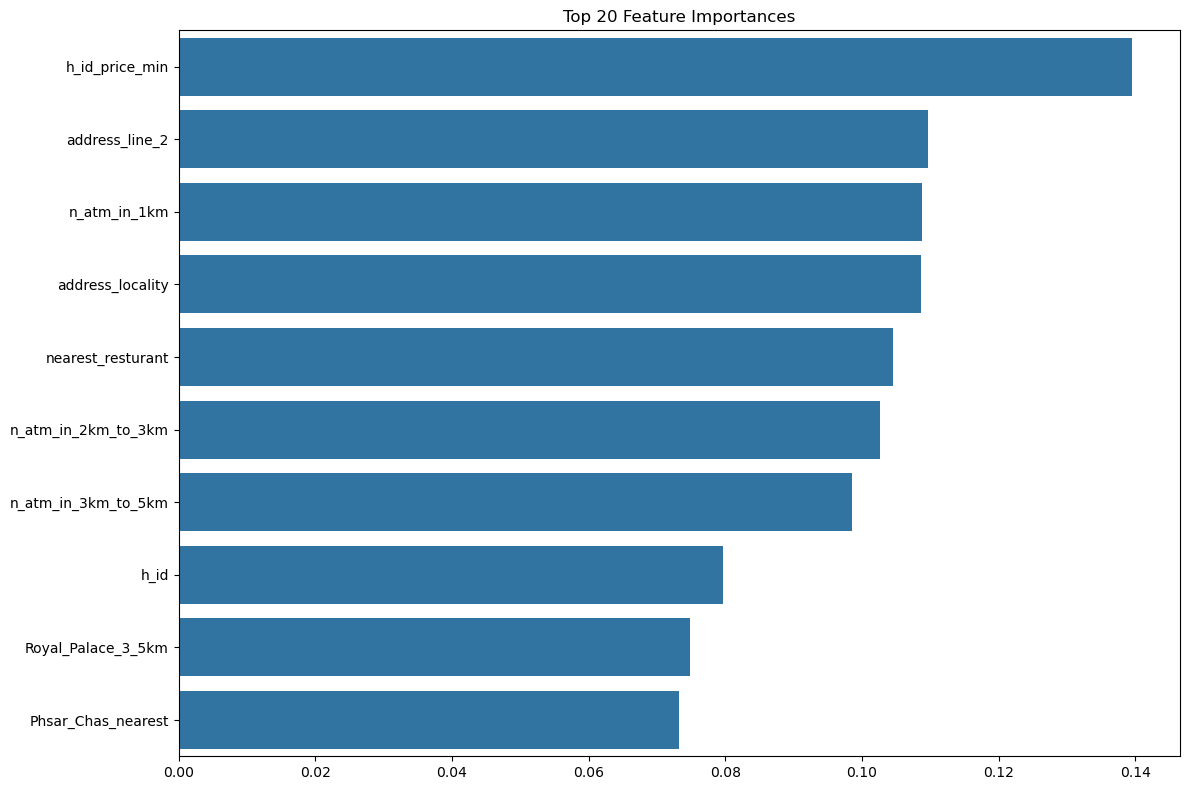

In [26]:
feature_importance = best_xgb.feature_importances_
sorted_idx = np.argsort(feature_importance)[::-1]
sorted_features = [X.columns[i] for i in sorted_idx]

plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importance[sorted_idx][:20], y=sorted_features[:20])
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.savefig("xgboost_feature_importances.png", dpi=300)
plt.show()

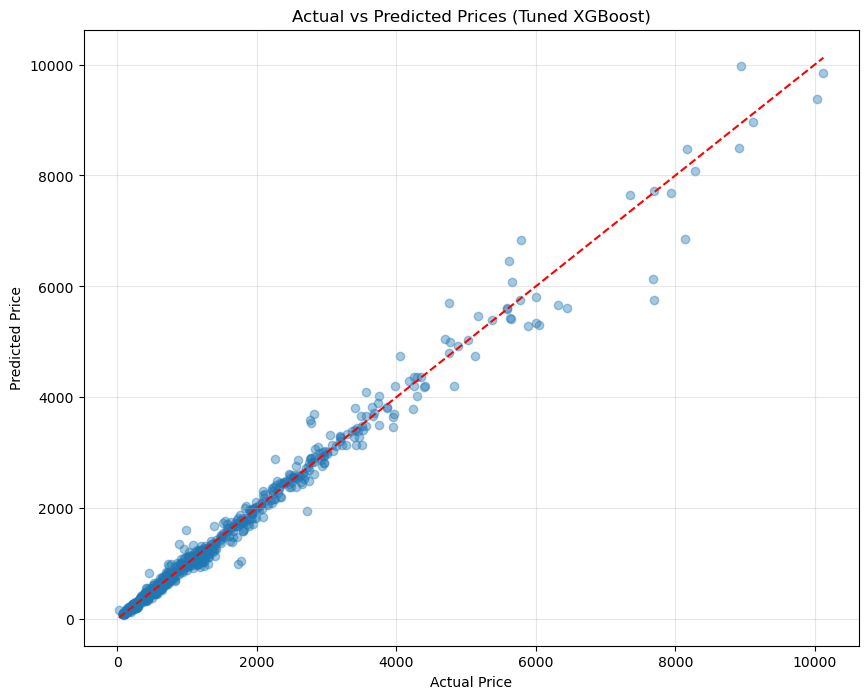

In [27]:
# Actual vs Predicted Plot
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_test, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices (Tuned XGBoost)")
plt.grid(alpha=0.3)
plt.savefig("tuned_xgboost_actual_vs_predicted.png", dpi=300)
plt.show()

In [28]:
def calculate_metrics(model, X_train, y_train, X_test, y_test, cv_folds=5):
    # Train set predictions
    y_pred_train = model.predict(X_train)
    
    # Test set predictions
    y_pred_test = model.predict(X_test)
    
    # Calculate metrics for test set
    test_r2 = r2_score(y_test, y_pred_test)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mape = np.mean(np.abs((y_test - y_pred_test) / np.maximum(y_test, 1))) * 100
    
    # Calculate train R2
    train_r2 = r2_score(y_train, y_pred_train)
    
    
    # Create metrics dataframe
    metrics_df = pd.DataFrame({
        'Metric': ['R2(Test)', 'MAE', 'RMSE', 'MAPE', 'Train R2'],
        'Value': [test_r2, test_mae, test_rmse, test_mape, train_r2]
    })
    
    return metrics_df.round(4)

In [29]:
metrics_df = calculate_metrics(best_xgb, X_train, y_train, X_test, y_test)
print("\nModel Performance Metrics:")
print("="*50)
print(metrics_df.to_string(index=False))
print("="*50)


Model Performance Metrics:
  Metric    Value
R2(Test)   0.9857
     MAE  83.3816
    RMSE 180.7110
    MAPE   8.0824
Train R2   0.9985


In [30]:
# joblib.dump(best_xgb, "../../../models/xgboost/xgboost_model_label_v3.joblib")